# Station validation

Evaluates CNN and Attention CNN predictions (1 km → 250 m)
against daily temperature measurements from CoAgMET and SNOTEL stations
in the Colorado Front Range for 2023.

**Note:** MODIS LST is a daytime skin temperature, while station data
are 24-hour average air temperatures. Expect a systematic warm bias in
the predictions relative to stations; the temporal pattern and relative
model ranking remain informative.

## 0 — Setup

In [1]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q rasterio geopandas h5py huggingface_hub scikit-learn pyproj
    if not os.path.isdir('downscaling'):
        !git clone -q https://github.com/fresleven/downscaling.git
    %cd downscaling
    sys.path.insert(0, '.')
else:
    sys.path.insert(0, os.path.abspath('../..'))


In [2]:
import csv
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from collections import defaultdict
from pyproj import Transformer
from rasterio.transform import rowcol

DATA_ROOT   = 'data'
RESULTS     = 'results'
STATION_DIR = f'{DATA_ROOT}/stations'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


## 1 — Load station metadata & 2023 measurements

In [3]:
# ── Station metadata (lat/lon) ──────────────────────────────────────────
station_meta = {}  # {name: {id, dataset, lat, lon}}
with open(f'{STATION_DIR}/final_stations.csv', newline='') as f:
    for row in csv.DictReader(f):
        name = row['station_name'].strip()
        station_meta[name] = {
            'id':      row['id'].strip(),
            'dataset': row['dataset'].strip(),
            'lat':     float(row['latitude']),
            'lon':     float(row['longitude']),
        }

# ── CoAgMET: daily avg temp (°F) → °C for 2023 ───────────────────────
# File rows: id, date (M/D/YY), avg temp (deg F), ...
coagmet_raw = defaultdict(dict)  # {station_id_upper: {date_str: temp_C}}
with open(f'{STATION_DIR}/coagmet.csv', newline='') as f:
    rows = list(csv.reader(f))
for row in rows[2:]:   # skip two header rows
    if len(row) < 3 or not row[2].strip():
        continue
    try:
        dt   = datetime.strptime(row[1].strip(), '%m/%d/%y')
        temp = (float(row[2].strip()) - 32) * 5 / 9
        coagmet_raw[row[0].strip().upper()][dt.strftime('%Y-%m-%d')] = temp
    except (ValueError, TypeError):
        pass

# ── SNOTEL: wide format, water-year columns, °F → °C ──────────────────
# Water year Y = Oct (Y-1) – Sep Y.
# Calendar 2023: months 01-09 from col '2023'; months 10-12 from col '2024'.
SNOTEL_FILES = {
    'Berthoud Summit':   f'{STATION_DIR}/Berthoud Summit.csv',
    'Echo Lake':         f'{STATION_DIR}/Echo Lake.csv',
    'Jackwhacker Gulch': f'{STATION_DIR}/Jackwhacker Gulch.csv',
    'Lake Eldora':       f'{STATION_DIR}/Lake Eldora.csv',
}

snotel_raw = {}  # {station_name: {date_str: temp_C}}
for name, path in SNOTEL_FILES.items():
    snotel_raw[name] = {}
    with open(path, newline='') as f:
        rows = list(csv.reader(f))
    header = rows[0]
    try:
        col_wy2023 = header.index('2023')  # water year 2023 = Oct 2022 - Sep 2023
        col_wy2024 = header.index('2024')  # water year 2024 = Oct 2023 - Sep 2024
    except ValueError:
        continue
    for row in rows[1:]:
        if not row or not row[0].strip():
            continue
        try:
            month, day = map(int, row[0].strip().split('-'))
        except ValueError:
            continue
        # months 1-9 come from WY2023 (= calendar 2023); months 10-12 from WY2024 (= calendar 2023)
        col = col_wy2023 if month <= 9 else col_wy2024
        if col >= len(row) or not row[col].strip():
            continue
        try:
            temp_c = (float(row[col].strip()) - 32) * 5 / 9
            dt = datetime(2023, month, day)
            snotel_raw[name][dt.strftime('%Y-%m-%d')] = temp_c
        except (ValueError, OverflowError):
            pass  # e.g. Feb 29 in non-leap year

# ── Unify into station_measurements ──────────────────────────────────
station_measurements = {}  # {station_name: {date_str: temp_C}}
for name, meta in station_meta.items():
    if meta['dataset'] == 'coagmet':
        sid = meta['id'].upper()
        if sid in coagmet_raw:
            station_measurements[name] = {
                d: t for d, t in coagmet_raw[sid].items() if d.startswith('2023')
            }
    elif name in snotel_raw:
        station_measurements[name] = snotel_raw[name]

print('Station\t\t\t\t\t2023 days')
for name, data in station_measurements.items():
    print(f'  {name:<35s} {len(data)}')


Station					2023 days
  Cherry Creek Reservoir              365
  Chatfield at South Platte Reservoir 365
  Denver                              365
  Boulder South West                  365
  Echo Lake                           365
  Jackwhacker Gulch                   365
  Berthoud Summit                     361
  Lake Eldora                         364


## 2 — Load 250 m dataset & models

The saved model weights were trained on 4 km → 1 km (4× upscaling). The same
architecture applies to 1 km → 250 m (also 4×) using finer covariates
(250 m native NDVI, DEM).

In [4]:
from model.dataset import DownscalingDataset
from model.cnn import GuidedCNN
from model.attention_cnn import AttentionAugmentedCNN

# 1 km LR → 250 m HR, test split (2023)
ds_250 = DownscalingDataset(
    root=DATA_ROOT, split='test', lr_res='1km', hr_res='250m', download=False
)
print(f'250 m dataset: {len(ds_250.dates)} test dates, {len(ds_250.split_blocks)} test blocks')
print(f'HR shape: {ds_250.hr_shape},  LR shape: {ds_250.lr_shape}')

# The saved weights were trained on 4km→1km data whose LULC classes may differ
# from the 250m reprojection. Load a 1km reference dataset to get the exact
# class list used during training, then override ds_250 so lulc_onehot matches.
ds_ref = DownscalingDataset(
    root=DATA_ROOT, split='test', lr_res='4km', hr_res='1km', download=False
)
train_lulc_classes = ds_ref.lulc_classes
ds_250.lulc_classes = train_lulc_classes   # ensure __getitem__ builds matching onehot
n_classes = len(train_lulc_classes)
print(f'LULC classes used for model ({n_classes}): {train_lulc_classes.tolist()}')

ds_date_to_idx = {d.strftime('%Y-%m-%d'): i for i, (d, _) in enumerate(ds_250.dates)}

# CNN: cov = NDVI + DEM + LULC_onehot + loc  →  1+1+n_classes+2 channels
cnn_model = GuidedCNN(
    cov_channels=1 + 1 + n_classes + 2,
    base_channels=64, n_lr_blocks=4, n_hr_blocks=6, dropout=0.1,
).to(device)
cnn_model.load_state_dict(torch.load('cnn_baseline.pt', map_location=device))
cnn_model.eval()

# Attention CNN: cov = NDVI + DEM + LULC_onehot (no loc)  →  1+1+n_classes channels
attn_model = AttentionAugmentedCNN(
    cov_channels=1 + 1 + n_classes,
    base_channels=64, n_lr_blocks=4, n_hr_blocks=6, dropout=0.1,
).to(device)
attn_model.load_state_dict(torch.load('attention_cnn.pt', map_location=device))
attn_model.eval()

def _make_cov_cnn(b):
    return torch.cat([b['ndvi'], b['dem'], b['lulc_onehot'], b['loc']], dim=1)

def _make_cov_attn(b):
    return torch.cat([b['ndvi'], b['dem'], b['lulc_onehot']], dim=1)

print('Models loaded.')


250 m dataset: 297 test dates, 6 test blocks
HR shape: (446, 347),  LR shape: (112, 87)
LULC classes used for model (15): [0, 11, 21, 22, 23, 24, 31, 41, 42, 52, 71, 81, 82, 90, 95]
Models loaded.


## 3 — Map station lat/lon → 250 m pixel locations

In [10]:
proj = Transformer.from_crs('EPSG:4326', ds_250.hr_crs, always_xy=True)
H_250, W_250 = ds_250.hr_shape

station_pixels = {}  # {name: {block_id, row_in_block, col_in_block}}
for name, meta in station_meta.items():
    if name not in station_measurements:
        continue
    x, y = proj.transform(meta['lon'], meta['lat'])
    r, c = rowcol(ds_250.hr_transform, x, y)
    r = int(np.clip(r, 0, H_250 - 1))
    c = int(np.clip(c, 0, W_250 - 1))
    block_id = int(ds_250.block_id[r, c])
    r0, r1, c0, c1 = ds_250.block_bboxes[block_id]
    station_pixels[name] = {
        'block_id':     block_id,
        'row_in_block': r - r0,
        'col_in_block': c - c0,
    }
    split = ds_250.block_assignment[block_id]
    print(f'{name:<35s}  block {block_id:2d} ({split:5s})  pixel ({r:3d}, {c:3d})')

inference_blocks = sorted({v['block_id'] for v in station_pixels.values()})
print(f'\nBlocks to run inference on: {inference_blocks}')


Cherry Creek Reservoir               block 11 (val  )  pixel (167, 341)
Chatfield at South Platte Reservoir  block 16 (train)  pixel (181, 265)
Denver                               block  5 (train)  pixel ( 88, 292)
Boulder South West                   block  3 (test )  pixel (  3, 200)
Echo Lake                            block  7 (train)  pixel (144,  80)
Jackwhacker Gulch                    block 12 (val  )  pixel (181,   8)
Berthoud Summit                      block  0 (val  )  pixel ( 78,  17)
Lake Eldora                          block  1 (train)  pixel ( 19,  82)

Blocks to run inference on: [0, 1, 3, 5, 7, 11, 12, 16]


## 4 — Run 1 km → 250 m inference at station blocks for all 2023 test dates

Only the blocks containing at least one station are computed, keeping runtime short.

In [6]:
all_blocks = sorted(ds_250.block_bboxes.keys())  # all 30 blocks

def predict_block(model, ds, date_idx, block_id, make_cov_fn, all_blocks, device):
    """Run model on one block; returns (bH, bW) numpy array."""
    orig_split = ds.split_blocks
    ds.split_blocks = all_blocks
    blk_idx = all_blocks.index(block_id)
    sample  = ds[date_idx * len(all_blocks) + blk_idx]
    r0, r1, c0, c1 = ds.block_bboxes[block_id]
    bH, bW = r1 - r0, c1 - c0
    b = {k: v.unsqueeze(0).to(device) if torch.is_tensor(v) else v
         for k, v in sample.items()}
    with torch.no_grad():
        pr = model(b['lr_lst'], make_cov_fn(b), b['lr_mask'],
                   b['lr_bicubic']).squeeze().cpu().numpy()
    ds.split_blocks = orig_split
    return pr[:bH, :bW]


# station_name → {date_str: {'cnn': float, 'attn': float}}
predictions = defaultdict(dict)

for i, (dt, _) in enumerate(ds_250.dates):
    date_str = dt.strftime('%Y-%m-%d')
    # cache block predictions for this date
    block_cache = {}
    for bid in inference_blocks:
        block_cache[(bid, 'cnn')]  = predict_block(cnn_model,  ds_250, i, bid, _make_cov_cnn,  all_blocks, device)
        block_cache[(bid, 'attn')] = predict_block(attn_model, ds_250, i, bid, _make_cov_attn, all_blocks, device)

    for name, pix in station_pixels.items():
        rb, cb, bid = pix['row_in_block'], pix['col_in_block'], pix['block_id']
        predictions[name][date_str] = {
            'cnn':  float(block_cache[(bid, 'cnn')][rb, cb]),
            'attn': float(block_cache[(bid, 'attn')][rb, cb]),
        }

    if i % 50 == 0:
        print(f'  {i}/{len(ds_250.dates)}  {date_str}')

print('Inference complete.')


  0/297  2023-01-03
  50/297  2023-03-03
  100/297  2023-05-05
  150/297  2023-07-08
  200/297  2023-08-30
  250/297  2023-10-27
Inference complete.


## 5 — RMSE vs time (monthly) & per-station time series

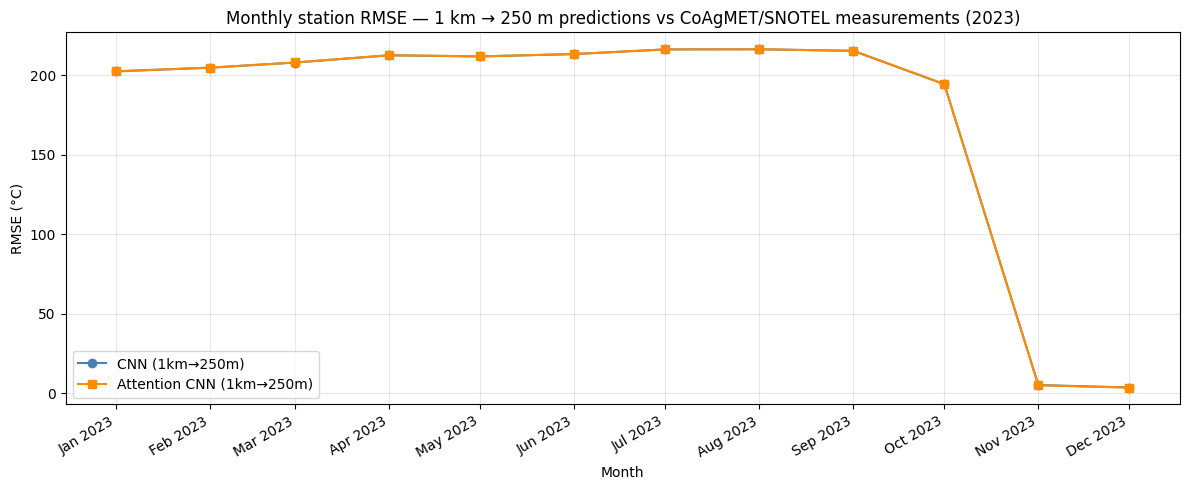

                                     n days  CNN RMSE (°C)  Attn RMSE (°C)
Station                                                                   
Cherry Creek Reservoir                  297          12.52           12.25
Chatfield at South Platte Reservoir     297          10.65           11.03
Denver                                  297         545.46          545.60
Boulder South West                      297           9.80            9.23
Echo Lake                               297           5.67            5.64
Jackwhacker Gulch                       297           7.78            7.47
Berthoud Summit                         293           7.13            7.24
Lake Eldora                             296           4.91            5.05


,n days,CNN RMSE (°C),Attn RMSE (°C)
Station,,,
Cherry Creek Reservoir,297,12.52,12.25
Chatfield at South Platte Reservoir,297,10.65,11.03
Denver,297,545.46,545.60
Boulder South West,297,9.80,9.23
Echo Lake,297,5.67,5.64
Jackwhacker Gulch,297,7.78,7.47
Berthoud Summit,293,7.13,7.24
Lake Eldora,296,4.91,5.05


In [7]:
# ── Monthly RMSE across all stations ──────────────────────────────────
monthly = defaultdict(lambda: {'cnn': [], 'attn': []})

for name, pix_preds in predictions.items():
    measured = station_measurements.get(name, {})
    for date_str, preds in pix_preds.items():
        if date_str not in measured:
            continue
        t = measured[date_str]
        if not np.isfinite(t):
            continue
        mo = date_str[:7]  # 'YYYY-MM'
        monthly[mo]['cnn'].append( (preds['cnn']  - t) ** 2)
        monthly[mo]['attn'].append((preds['attn'] - t) ** 2)

months       = sorted(monthly.keys())
month_dates  = [datetime.strptime(m, '%Y-%m') for m in months]
cnn_rmse_mo  = [np.sqrt(np.mean(monthly[m]['cnn']))  for m in months]
attn_rmse_mo = [np.sqrt(np.mean(monthly[m]['attn'])) for m in months]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(month_dates, cnn_rmse_mo,  marker='o', color='steelblue',  label='CNN (1km→250m)')
ax.plot(month_dates, attn_rmse_mo, marker='s', color='darkorange', label='Attention CNN (1km→250m)')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
ax.set_xlabel('Month')
ax.set_ylabel('RMSE (\u00b0C)')
ax.set_title('Monthly station RMSE — 1 km → 250 m predictions vs CoAgMET/SNOTEL measurements (2023)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
import pandas as pd
rows = []
for name in station_pixels:
    measured = station_measurements.get(name, {})
    errs = {'cnn': [], 'attn': []}
    for date_str, preds in predictions[name].items():
        if date_str not in measured or not np.isfinite(measured[date_str]):
            continue
        t = measured[date_str]
        errs['cnn'].append( (preds['cnn']  - t) ** 2)
        errs['attn'].append((preds['attn'] - t) ** 2)
    rows.append({
        'Station': name,
        'n days':  len(errs['cnn']),
        'CNN RMSE (\u00b0C)':  round(float(np.sqrt(np.mean(errs['cnn']))),  2) if errs['cnn']  else float('nan'),
        'Attn RMSE (\u00b0C)': round(float(np.sqrt(np.mean(errs['attn']))), 2) if errs['attn'] else float('nan'),
    })
df = pd.DataFrame(rows).set_index('Station')
print(df.to_string())
df


In [11]:
true_station_pixels = station_pixels.copy()

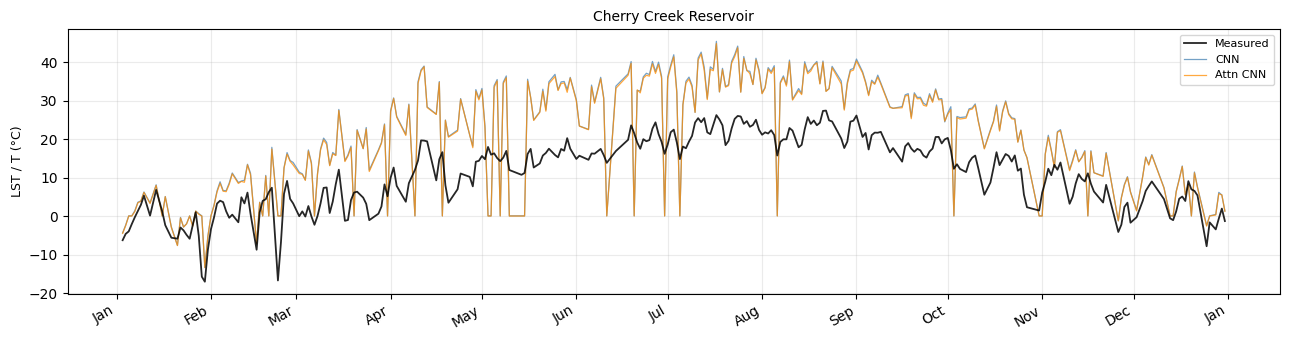

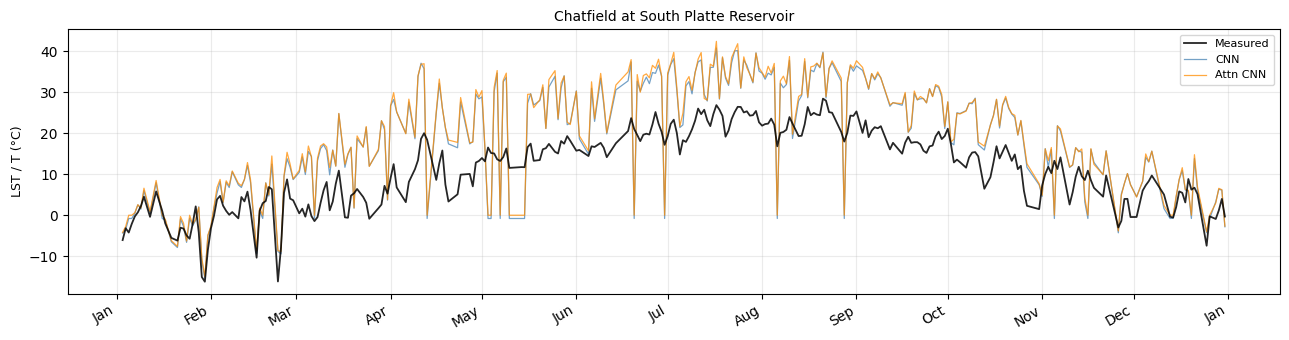

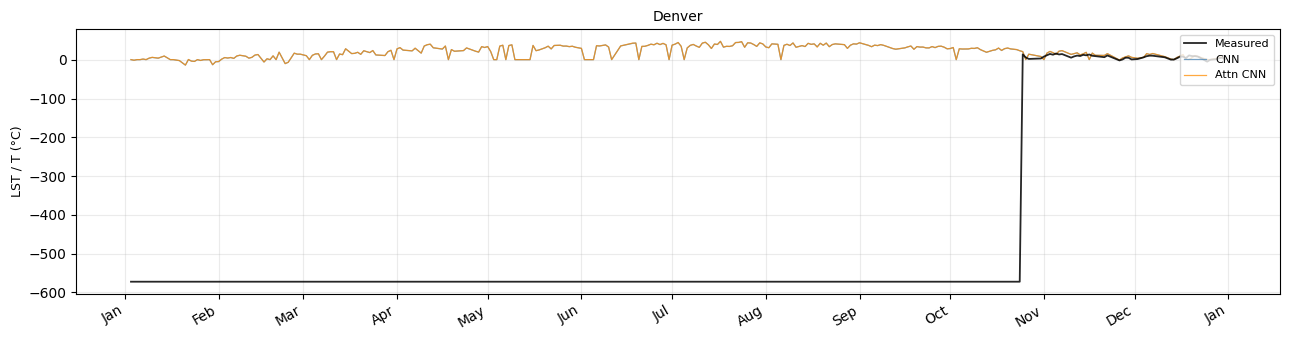

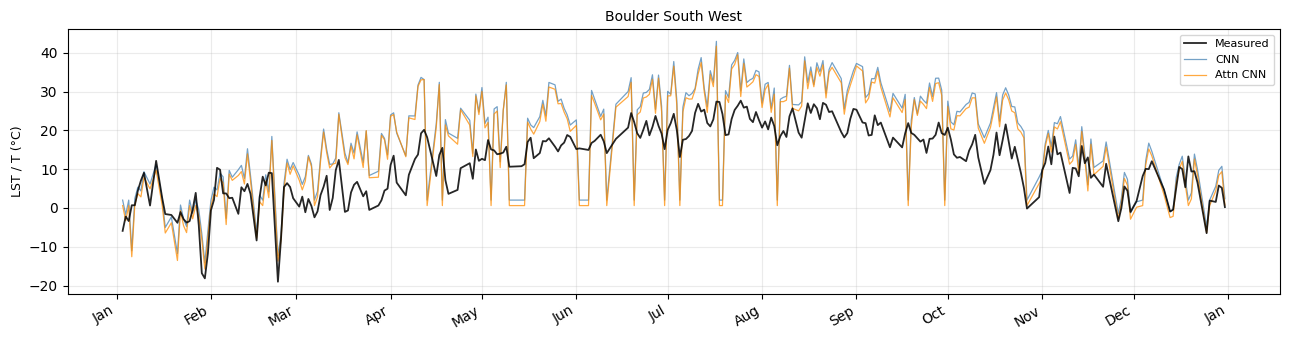

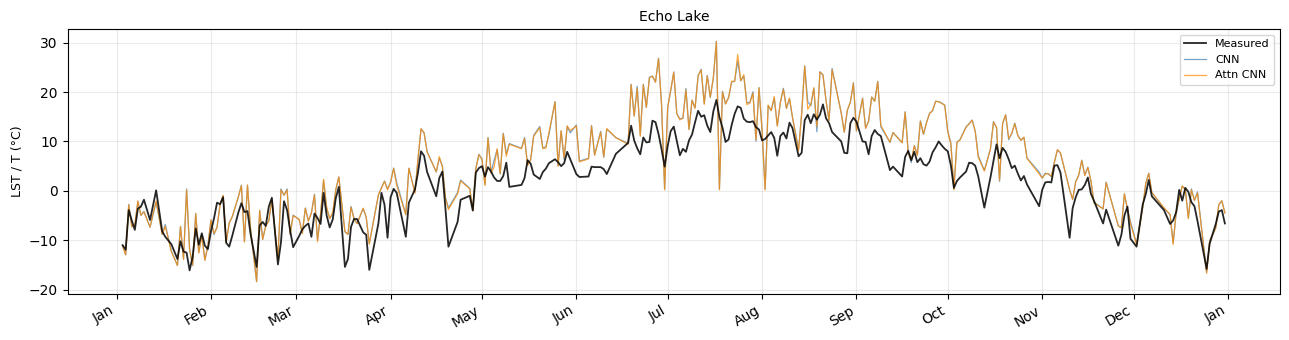

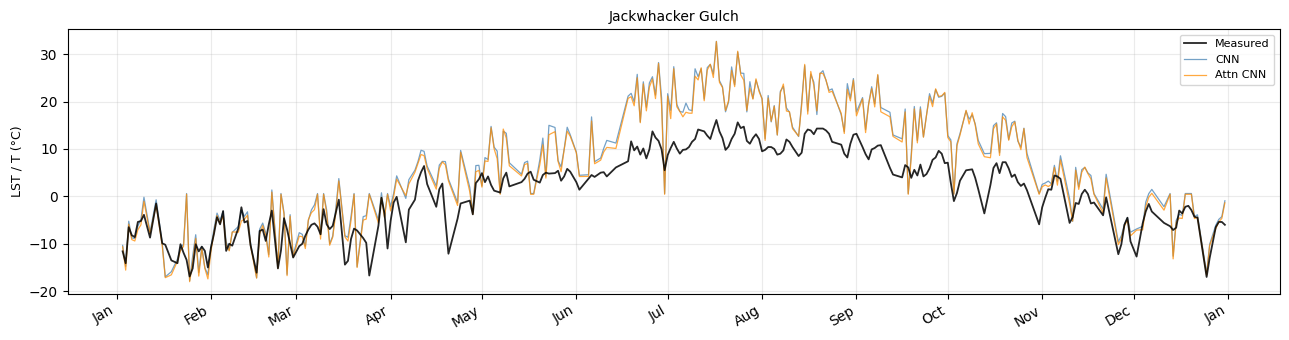

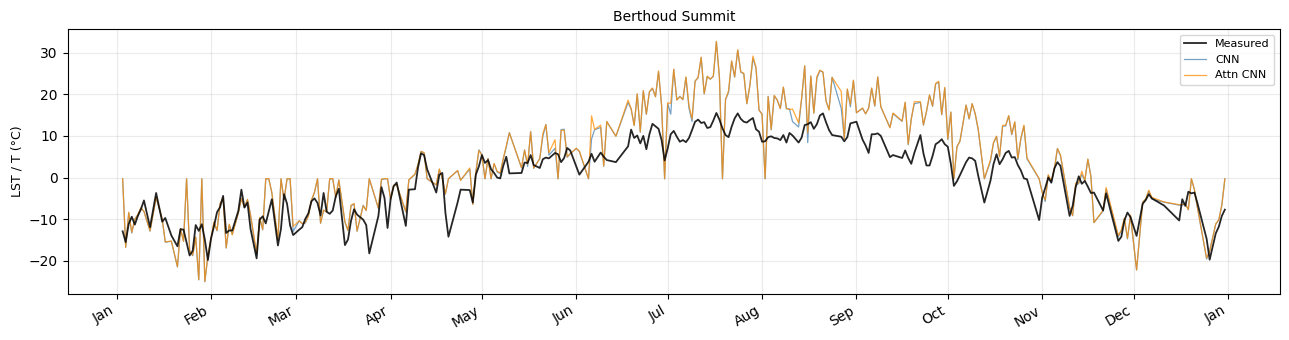

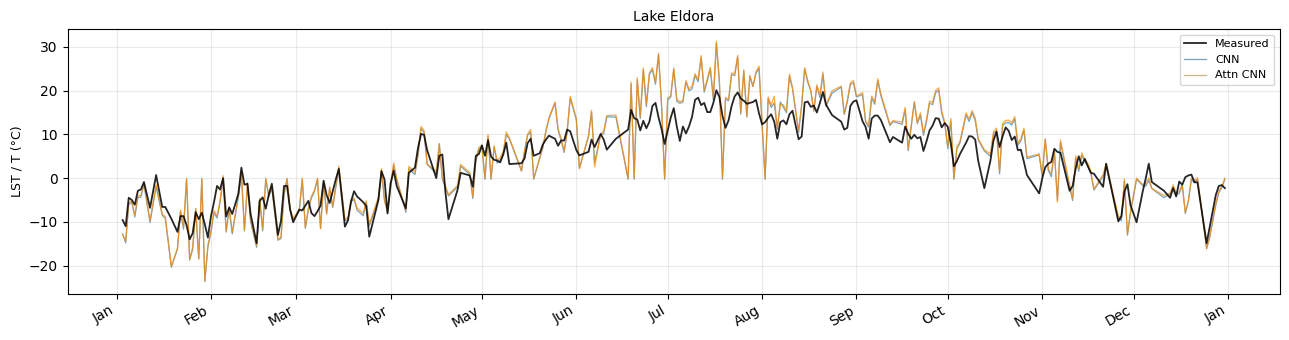

In [20]:
# ── Per-station time series: measured vs CNN vs Attention CNN ──────────
# station_pixels.pop('Denver')
for name in true_station_pixels:
    station_pixels = {name: true_station_pixels[name]}
    n_stations = len(station_pixels)
    fig, axes = plt.subplots(n_stations, 1,
                            figsize=(13, 3.5 * n_stations), sharex=True)
    if n_stations == 1:
        axes = [axes]

    for ax, name in zip(axes, station_pixels):
        measured = station_measurements.get(name, {})
        dates_both = sorted(
            d for d in predictions[name]
            if d in measured and np.isfinite(measured[d])
        )
        if not dates_both:
            ax.set_title(f'{name} (no overlapping data)')
            continue
        dt_list   = [datetime.strptime(d, '%Y-%m-%d') for d in dates_both]
        obs_list  = [measured[d]                       for d in dates_both]
        cnn_list  = [predictions[name][d]['cnn']        for d in dates_both]
        attn_list = [predictions[name][d]['attn']       for d in dates_both]

        ax.plot(dt_list, obs_list,  color='black',      lw=1.3, label='Measured', alpha=0.85, zorder=3)
        ax.plot(dt_list, cnn_list,  color='steelblue',  lw=0.9, label='CNN',       alpha=0.75)
        ax.plot(dt_list, attn_list, color='darkorange',  lw=0.9, label='Attn CNN',  alpha=0.75)
        ax.set_ylabel('LST / T (\u00b0C)', fontsize=9)
        ax.set_title(name, fontsize=10)
        ax.grid(alpha=0.25)

    axes[0].legend(loc='upper right', fontsize=8)
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
    # plt.suptitle('Station predictions vs measurements — 1 km \u2192 250 m — 2023', fontsize=11)
    plt.savefig(f'time_series_{name}.pdf', bbox_inches='tight')
    plt.tight_layout()
    plt.show()
